# Task 2 - Detection

## Import and setup

In [1]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch
from tqdm.notebook import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [2]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [3]:
# same config as in SFA3d

config = edict()
config.lims = edict()
config.lims.x = [0, 50]
config.lims.y = [-25, 25]
config.lims.z = [-1, 3]
config.lims.intensity = [0, 1]
config.bev_height = 608
config.bev_width = 608

In [4]:
def pcl_to_bev(pcl: np.ndarray, config: edict) -> np.ndarray:
    """SFA3D-style BEV map creation while maintaining compatibility with your config structure
    
    Args:
        pcl: pointcloud as numpy array [n_points, m_channels]
        configs: configuration parameters containing:
            lims: dictionary with detection limits
                x: [min_x, max_x] x-axis limits in meters
                y: [min_y, max_y] y-axis limits in meters 
                z: [min_z, max_z] z-axis limits in meters
                intensity: [min_intensity, max_intensity] intensity value limits
            bev_height: height of output BEV map in pixels
            bev_width: width of output BEV map in pixels
    Returns:
        RGB_Map: BEV map as [3, height, width] array
    """
    # Create copy to avoid modifying original
    points = np.copy(pcl)
    
    # Filter points within detection range
    mask = np.where((points[:, 0] >= config.lims.x[0]) & (points[:, 0] <= config.lims.x[1]) &
                    (points[:, 1] >= config.lims.y[0]) & (points[:, 1] <= config.lims.y[1]) &
                    (points[:, 2] >= config.lims.z[0]) & (points[:, 2] <= config.lims.z[1]))
    points = points[mask]
    
    # Adjust height relative to ground (as in your implementation)
    points[:, 2] = points[:, 2] - config.lims.z[0]
    
    height = config.bev_height + 1
    width = config.bev_width + 1
    
    # Calculate discretization (similar to your bev_x_discret and bev_y_discret)
    x_discretization = (config.lims.x[1] - config.lims.x[0]) / config.bev_height
    y_discretization = (config.lims.y[1] - config.lims.y[0]) / config.bev_width
    
    # Discretize Feature Map (SFA3D style)
    points[:, 0] = np.int_(np.floor(points[:, 0] / x_discretization))  # Forward direction
    points[:, 1] = np.int_(np.floor(points[:, 1] / y_discretization) + width / 2)

    
    # Sort points (SFA3D style)
    sorted_indices = np.lexsort((-points[:, 2], points[:, 1], points[:, 0]))
    points = points[sorted_indices]
    _, unique_indices, unique_counts = np.unique(points[:, 0:2], axis=0, return_index=True, return_counts=True)
    points_top = points[unique_indices]
    
    # Initialize maps
    heightMap = np.zeros((height, width))
    intensityMap = np.zeros((height, width))
    densityMap = np.zeros((height, width))
    
    # Fill maps (SFA3D style)
    max_height = float(np.abs(config.lims.z[1] - config.lims.z[0]))
    heightMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = points_top[:, 2] / max_height
    
    # Clip intensity values and normalize
    clipped_intensities = np.clip(points_top[:, 3], config.lims.intensity[0], config.lims.intensity[1])
    intensityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = clipped_intensities / (config.lims.intensity[1])
    
    # Density map using log normalization as in SFA3D
    densityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = np.minimum(1.0, np.log(unique_counts + 1) / np.log(64))

    # Create RGB Map (same channel ordering as SFA3D)
    bev = np.zeros((3, height - 1, width - 1))
    bev[2, :, :] = densityMap[:config.bev_height, :config.bev_width]  # r_map
    bev[1, :, :] = heightMap[:config.bev_height, :config.bev_width]   # g_map
    bev[0, :, :] = intensityMap[:config.bev_height, :config.bev_width]# b_map
    
    return bev

In [5]:
def _draw_box(config, ax, pos, scale, rotation, color, linestyle='-', label=None):
        x, y = pos[0], pos[1]  # Forward, left coordinates
        l, w = scale[0], scale[1]  # Length, width
        
        # Create rectangle points (in world coordinates)
        corners = np.array([
            [-l/2, -w/2],
            [l/2, -w/2],
            [l/2, w/2],
            [-l/2, w/2]
        ])
        
        # Rotate corners
        rot_matrix = np.array([
            [np.cos(rotation[2]), -np.sin(rotation[2])],
            [np.sin(rotation[2]), np.cos(rotation[2])]
        ])
        rotated_corners = corners @ rot_matrix.T
        
        # Convert each corner to pixel coordinates
        pixel_corners = []
        for dx, dy in rotated_corners:
            px, py = _world_to_pixel(x + dx, y + dy, config)
            pixel_corners.append([px, py])
        
        # Draw the box
        pixel_corners = np.array(pixel_corners)
        pixel_corners = np.vstack([pixel_corners, pixel_corners[0]])  # Close the rectangle
        ax.plot(pixel_corners[:, 1], pixel_corners[:, 0],  # Note: x and y are swapped for imshow
                color=color, linestyle=linestyle, label=label)

# Helper function to convert real-world coordinates to pixel coordinates
def _world_to_pixel(x, y, config):
    """Convert world coordinates to pixel coordinates based on config limits"""
    x_discretization = (config.lims.x[1] - config.lims.x[0]) / config.bev_height
    y_discretization = (config.lims.y[1] - config.lims.y[0]) / config.bev_width
    
    # Convert x coordinate (forward direction)
    # Match SFA3D's coordinate system - no inversion needed
    pixel_x = int(x / x_discretization)
    
    # Convert y coordinate (lateral direction)
    # Add width/2 to center the coordinate system
    pixel_y = int(y / y_discretization + config.bev_width / 2)
    
    return pixel_x, pixel_y

def visualize_bev(bev: np.ndarray, config: edict = None, predictions: np.ndarray = None, ground_truth: np.ndarray = None, show_channels: bool = True):
    """
    Visualize Bird's Eye View (BEV) data both as a combined map and individual channels
    
    Args:
        bev: numpy array of shape (channels, height, width)
        config: configuration parameters containing:
            lims: dictionary with detection limits
                x: [min_x, max_x] x-axis limits in meters
                y: [min_y, max_y] y-axis limits in meters 
                z: [min_z, max_z] z-axis limits in meters
                intensity: [min_intensity, max_intensity] intensity value limits
        predictions: list of prediction dictionaries (optional)
        ground_truth: list of ground truth dictionaries (optional)
    """

    # if predictions or ground_truth are provided, then config is required
    if predictions is not None or ground_truth is not None:
        if config is None:
            raise ValueError("config is required when predictions or ground_truth are provided")

    # Create a figure with a grid layout
    plt.figure(figsize=(12, 15), constrained_layout=True)
    
    # Create grid spec to control subplot sizes
    if show_channels:
        gs = plt.GridSpec(2, 3, height_ratios=[2, 1], width_ratios=[1, 1, 1], hspace=0.1, wspace=0.1)
    else:
        gs = plt.GridSpec(1, 1)
    
    # Plot combined BEV map spanning full width
    ax1 = plt.subplot(gs[0, :])
    bev_map_display = np.transpose(bev, (1, 2, 0))
    im1 = ax1.imshow(bev_map_display, origin='lower')
    plt.colorbar(im1, ax=ax1)
    ax1.set_title("Combined Bird's Eye View Map")

    # Draw ground truth boxes
    if ground_truth:
        for gt in ground_truth:
            _draw_box(
                config,
                ax1,
                gt['pos'], 
                gt['scale'], 
                gt['rot'],
                color='g',
                linestyle='-',
                label='Ground Truth' if gt == ground_truth[0] else None
            )
    
    # Draw prediction boxes
    if predictions:
        for pred in predictions:
            _draw_box(
                config,
                ax1,
                pred['pos'], 
                pred['scale'], 
                pred['rot'],
                color='r',
                linestyle='--',
                label='Prediction' if pred == predictions[0] else None
            )
    
    plt.title("Bird's Eye View with Detections")
    plt.xlabel("Y (lateral)")
    plt.ylabel("X (forward)")
    
    if predictions or ground_truth:
        plt.legend()
    
    # Plot individual channels in bottom row
    if show_channels:
        titles = ['Density', 'Height', 'Intensity']
        for i, title in enumerate(titles):
            ax = plt.subplot(gs[1, i])
            im = ax.imshow(bev[i], origin='lower')
            plt.colorbar(im, ax=ax)
            ax.set_title(title)
    
    plt.show()



BEV shape: (3, 608, 608)


/home/lukas-kurz/Desktop/autonomous_driving/intro_to_autonomous_vehicles_2025/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


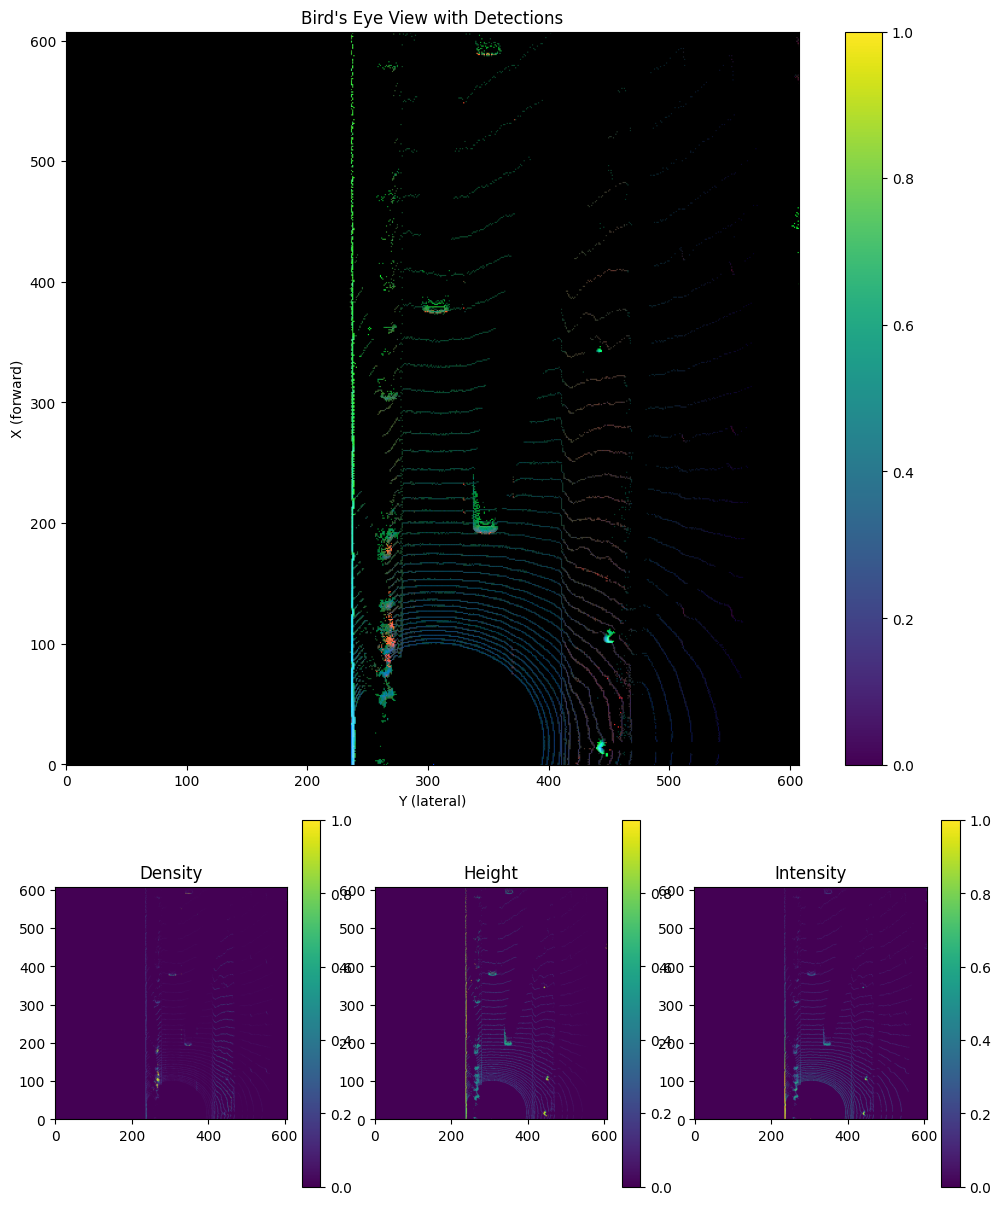

In [6]:
bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Create Dataset

In [7]:
class LidarDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir: str, config: edict):
        """
        Initialize the dataset
        Args:
            data_dir: path to dataset directory containing frame_*.pb files
            config: configuration dictionary with BEV parameters
        """
        self.data_dir = data_dir
        self.config = config
        
        # Get list of all frame files
        self.frame_files = []
        for file in sorted(os.listdir(data_dir)):
            if file.startswith('frame_') and file.endswith('.pb'):
                self.frame_files.append(os.path.join(data_dir, file))
                
        print(f"Found {len(self.frame_files)} frames")
        
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        """
        Get a single frame data
        Args:
            idx: frame index
        Returns:
            pointcloud: (N, 4) array of points (x,y,z,intensity)
        """
        # Read frame
        frame = dataset_tools.read_frame(self.frame_files[idx])
        
        # Get first lidar's pointcloud
        lidar = frame.lidars[0]
        pointcloud = dataset_tools.decode_lidar(lidar)
        detections = lidar.detections
        detections = self._filter_detections(detections)
        bev = pcl_to_bev(pointcloud, self.config)
        
        # Convert numpy array to pytorch tensor
        bev = torch.from_numpy(bev).float()
        
        return bev, detections

    def _filter_detections(self, detections: list) -> list:
        """
        Filter detections based on config limits
        """
        filtered_detections = []
        for det in detections:
            if det.pos[0] >= self.config.lims.x[0] and det.pos[0] <= self.config.lims.x[1] and \
                det.pos[1] >= self.config.lims.y[0] and det.pos[1] <= self.config.lims.y[1]:
                filtered_detections.append(det)
        return filtered_detections


# Create dataset
dataset = LidarDataset("dataset/data_2", config)

# Test loading first frame
bev, detections = dataset[0]
print(f"Loaded pointcloud shape: {bev.shape}")
print(f"Loaded {len(detections)} number of detections")
print(f"Detection 0: {detections[0]}")


Found 199 frames
Loaded pointcloud shape: torch.Size([3, 608, 608])
Loaded 2 number of detections
Detection 0: id: "jT38g8qP7TxoFXreShjseQ"
pos: 17.73561
pos: 3.5638618
pos: 0.9022855
rot: 0.0
rot: 0.0
rot: -0.0036740804
scale: 4.2737045
scale: 1.938453
scale: 1.69



## Feed into deep learning model to detect vehicles

In [8]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Define Model

In [9]:
from SFA3D.sfa.models.model_utils import create_model
from SFA3D.sfa.utils.evaluation_utils import decode, post_processing, convert_det_to_real_values
from SFA3D.sfa.utils.torch_utils import _sigmoid

model_config = edict({
    "saved_fn": "fpn_resnet_18",
    "arch": "fpn_resnet_18",
    "pretrained_path": "./SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth",
    "K": 50,
    "no_cuda": False,
    "gpu_idx": 0,
    "num_samples": None,
    "num_workers": 1,
    "batch_size": 1,
    "peak_thresh": 0.2,
    "save_test_output": False,
    "output_format": "image",
    "output_video_fn": "out_fpn_resnet_18",
    "output_width": 608,
})
model_config.pin_memory = True
model_config.distributed = False  # For testing on 1 GPU only

model_config.input_size = (config.bev_width, config.bev_height)
model_config.down_ratio = 4
model_config.hm_size = (config.bev_width // model_config.down_ratio, config.bev_height // model_config.down_ratio)

model_config.max_objects = 50

model_config.imagenet_pretrained = False
model_config.head_conv = 64
model_config.num_classes = 3
model_config.num_center_offset = 2
model_config.num_z = 1
model_config.num_dim = 3
model_config.num_direction = 2  # sin, cos

model_config.heads = {
    'hm_cen': model_config.num_classes,
    'cen_offset': model_config.num_center_offset,
    'direction': model_config.num_direction,
    'z_coor': model_config.num_z,
    'dim': model_config.num_dim
}
model_config.num_input_features = 4

model = create_model(model_config)
model.load_state_dict(torch.load(model_config.pretrained_path, map_location='cuda'))
model = model.to("cuda:0")
model.eval();


using ResNet architecture with feature pyramid


In [10]:
def detect_objects(model, bev, device, verbose=False):
    bev = bev.to(device)
    with torch.no_grad():
        outputs = model(bev)
        outputs['hm_cen'] = _sigmoid(outputs['hm_cen'])
        outputs['cen_offset'] = _sigmoid(outputs['cen_offset'])

    if verbose:
        # print dimensions of outputs
        print(f"hm_cen: {outputs['hm_cen'].size()}") # [1, 3, 152, 152] -> 3 classes
        print(f"cen_offset: {outputs['cen_offset'].size()}") # [1, 2, 152, 152] -> 2 offset values
        print(f"direction: {outputs['direction'].size()}") # [1, 2, 152, 152] -> 2 direction values
        print(f"z_coor: {outputs['z_coor'].size()}") # [1, 1, 152, 152] -> 1 z coordinate
        print(f"dim: {outputs['dim'].size()}") # [1, 3, 152, 152] -> 3 dimensions

    predicted_detections = decode(outputs['hm_cen'], outputs['cen_offset'], outputs['direction'], outputs['z_coor'], outputs['dim'], K=model_config.K)
    predicted_detections = predicted_detections.cpu().numpy().astype(np.float32)
    predicted_detections = post_processing(predicted_detections, model_config.num_classes, model_config.down_ratio, model_config.peak_thresh)
    predicted_detections = convert_det_to_real_values(predicted_detections[0]) # [cls_id, x, y, z, _h, w, l, _yaw]

    return predicted_detections


bev, detections = dataset[0]
# Add batch dimension
bev = bev.unsqueeze(0)  # Shape: [1, 3, 608, 608]
predicted_detections = detect_objects(model, bev, device)

print(f"Predicted detections: {predicted_detections.shape}")

Predicted detections: (2, 8)


## Evaluate detection performance

### Visual Evaluation

In [11]:
def convert_ground_truth_to_dict(detections):
    """
    Convert protobuf LidarDetection messages to dictionary format
    
    Args:
        detections: List of LidarDetection protobuf messages
    
    Returns:
        List of dictionaries with detection information
    """
    formatted_detections = []
    
    for det in detections:
        detection = {
            'id': det.id,
            'type': det.type,
            'pos': list(det.pos),
            'rot': list(det.rot),
            'scale': list(det.scale)
        }
        formatted_detections.append(detection)
    
    return formatted_detections

def convert_predictions_to_lidar_format(predictions, confidence_threshold=0.3):
    formatted_detections = []
    
    for pred in predictions:
        cls_id, x, y, z, _h, w, l, _yaw = pred
            
        detection = {
            'id': f'pred_{len(formatted_detections)}',
            'type': cls_id,  # Class ID
            'pos': [x, y, z],  # Invert x to match visualization coordinate system
            'rot': [0.0, 0.0, _yaw],
            'scale': [l, w, _h],  # dimensions
            'confidence': 1
        }
        
        formatted_detections.append(detection)
    
    return formatted_detections

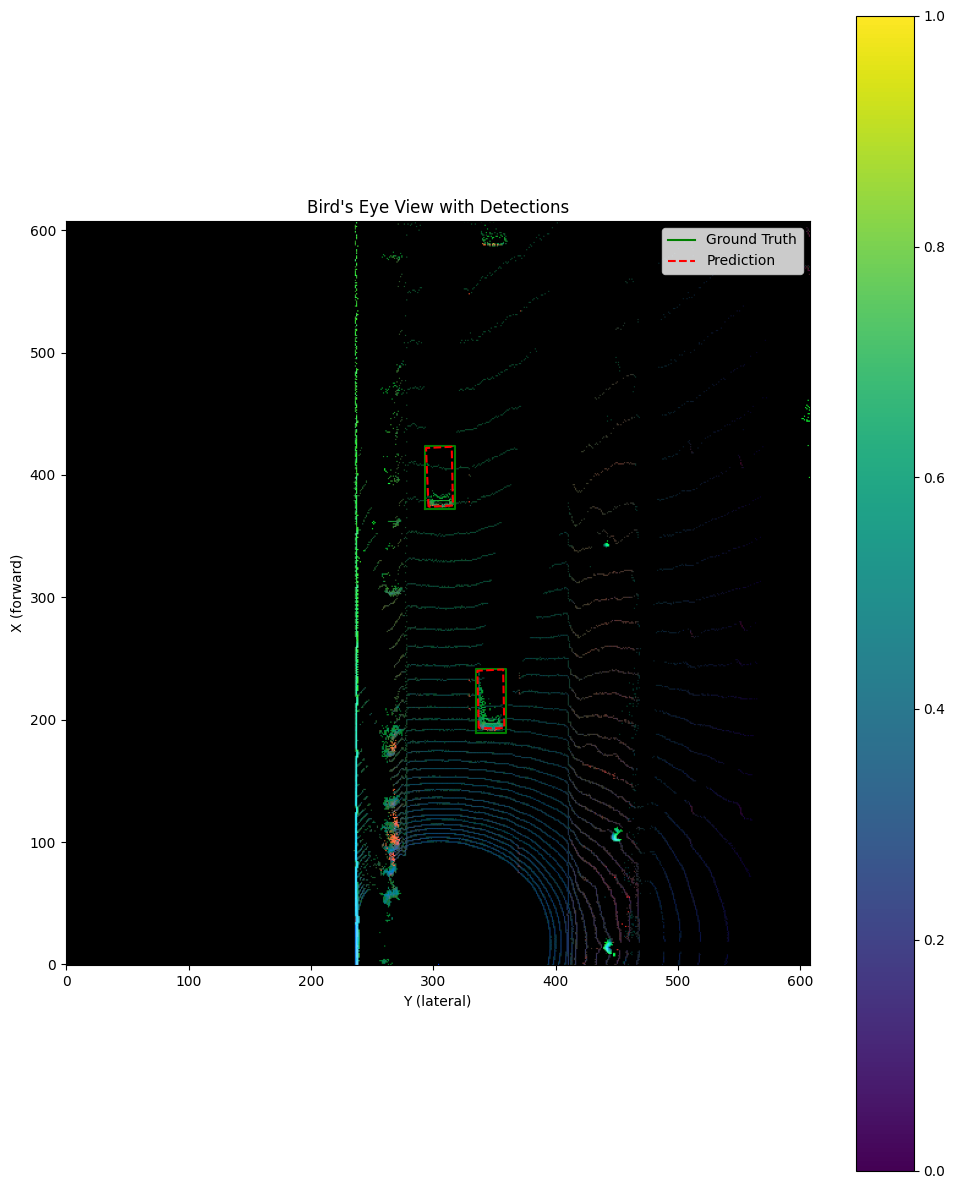

In [12]:
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Visualize
visualize_bev(
    bev.cpu().numpy().squeeze(0),
    predictions=pred_detections,
    ground_truth=gt_detections,
    config=config,
    show_channels=False
)

### Metrics for Evaluation

In [38]:
def calculate_iou_3d(pred_box: dict, gt_box: dict) -> float:
    """
    Calculate 3D IoU between predicted and ground truth boxes
    Args:
        pred_box: Dictionary containing 'pos', 'scale', and 'rot' keys
        gt_box: Dictionary containing 'pos', 'scale', and 'rot' keys
    Returns:
        iou: IoU score (simplified to 2D for BEV perspective)
    """
    # Extract positions and scales (we'll use 2D IoU from bird's eye view)
    pred_x, pred_y = pred_box['pos'][0], pred_box['pos'][1]
    pred_l, pred_w = pred_box['scale'][0], pred_box['scale'][1]
    
    gt_x, gt_y = gt_box['pos'][0], gt_box['pos'][1]
    gt_l, gt_w = gt_box['scale'][0], gt_box['scale'][1]
    
    # Calculate box coordinates (BEV perspective)
    x1_pred = pred_x - pred_l/2
    x2_pred = pred_x + pred_l/2
    y1_pred = pred_y - pred_w/2
    y2_pred = pred_y + pred_w/2
    
    x1_gt = gt_x - gt_l/2
    x2_gt = gt_x + gt_l/2
    y1_gt = gt_y - gt_w/2
    y2_gt = gt_y + gt_w/2
    
    # Calculate intersection
    x1_inter = max(x1_pred, x1_gt)
    y1_inter = max(y1_pred, y1_gt)
    x2_inter = min(x2_pred, x2_gt)
    y2_inter = min(y2_pred, y2_gt)
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    intersection = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    
    # Calculate areas
    area_pred = pred_l * pred_w
    area_gt = gt_l * gt_w
    
    # Calculate IoU
    union = area_pred + area_gt - intersection
    iou = intersection / union
    
    return iou

def evaluate_detections(pred_detections: list[dict], gt_detections: list[dict], 
                       iou_threshold: float = 0.5,
                       return_counts: bool = False) -> tuple:
    """
    Evaluate detection results
    Args:
        pred_detections: list of predicted detections in dictionary format
        gt_detections: list of ground truth detections in dictionary format
        iou_threshold: IoU threshold for considering a detection as correct
        return_counts: whether to return true_positives, false_positives, false_negatives
    Returns:
        if return_counts:
            precision, recall, f1_score, (true_positives, false_positives, false_negatives)
        else:
            precision, recall, f1_score
    """
     # Add at start of function
    if len(gt_detections) == 0:
        if len(pred_detections) == 0:
            return (1.0, 1.0, 1.0, (0, 0, 0)) if return_counts else (1.0, 1.0, 1.0)
        return (0.0, 0.0, 0.0, (0, len(pred_detections), 0)) if return_counts else (0.0, 0.0, 0.0)
    
    true_positives = 0
    false_positives = 0
    
    # Sort predictions by confidence if available
    if pred_detections and 'confidence' in pred_detections[0]:
        pred_detections = sorted(pred_detections, 
                               key=lambda x: x.get('confidence', 0), 
                               reverse=True)
    
    gt_matched = [False] * len(gt_detections)
    
    for pred in pred_detections:
        best_iou = 0
        best_gt_idx = -1
        
        # Find best matching ground truth
        for gt_idx, gt in enumerate(gt_detections):
            if gt_matched[gt_idx]:
                continue
                
            iou = calculate_iou_3d(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
        
        if best_iou >= iou_threshold:
            true_positives += 1
            gt_matched[best_gt_idx] = True
        else:
            false_positives += 1
    
    false_negatives = len(gt_detections) - true_positives
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    if return_counts:
        return precision, recall, f1_score, (true_positives, false_positives, false_negatives)
    return precision, recall, f1_score

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

def plot_evaluation_results(precisions, recalls, f1_scores, save_path=None):
    """
    Create a comprehensive visualization of detection results
    Args:
        precisions: List of precision values for each frame
        recalls: List of recall values for each frame
        f1_scores: List of F1 scores for each frame
        save_path: Optional path to save the figure
    """
    # Use a built-in style
    plt.style.use('default')
    fig = plt.figure(figsize=(15, 10))
    
    # 1. Metrics Distribution
    plt.subplot(2, 2, 1)
    data = [precisions, recalls, f1_scores]
    labels = ['Precision', 'Recall', 'F1-Score']
    box_plot = plt.boxplot(data, labels=labels, patch_artist=True)
    
    # Add colors to boxplots
    colors = ['lightblue', 'lightgreen', 'lightpink']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.title('Distribution of Metrics')
    plt.grid(True, alpha=0.3)
    
    # 2. Metrics Over Time
    plt.subplot(2, 2, 2)
    x = range(len(precisions))
    plt.plot(x, precisions, 'b-', label='Precision', alpha=0.7)
    plt.plot(x, recalls, 'g-', label='Recall', alpha=0.7)
    plt.plot(x, f1_scores, 'r-', label='F1-Score', alpha=0.7)
    plt.title('Metrics Over Time')
    plt.xlabel('Frame Number')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Precision-Recall Scatter
    plt.subplot(2, 2, 3)
    plt.scatter(recalls, precisions, c='blue', alpha=0.5)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision vs Recall')
    plt.grid(True, alpha=0.3)
    
    # 4. Metrics Summary
    plt.subplot(2, 2, 4)
    summary_data = {
        'Mean': [np.mean(precisions), np.mean(recalls), np.mean(f1_scores)],
        'Median': [np.median(precisions), np.median(recalls), np.median(f1_scores)],
        'Std': [np.std(precisions), np.std(recalls), np.std(f1_scores)]
    }
    
    cell_text = []
    for metric in ['Precision', 'Recall', 'F1-Score']:
        row = [f'{summary_data["Mean"][i]:.3f} ± {summary_data["Std"][i]:.3f}' 
               for i, m in enumerate([metric])]
        cell_text.append(row)
    
    table = plt.table(cellText=cell_text,
                     rowLabels=['Precision', 'Recall', 'F1-Score'],
                     colLabels=['Mean ± Std'],
                     loc='center',
                     cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    plt.axis('off')
    plt.title('Summary Statistics')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(true_positives, false_positives, false_negatives, save_path=None):
    """
    Create a confusion matrix visualization
    """
    plt.figure(figsize=(8, 6))
    cm = np.array([[true_positives, false_positives],
                   [false_negatives, 0]])  # Note: True Negatives aren't applicable
    
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    # Add text annotations
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.xticks([0, 1], ['Positive', 'Negative'])
    plt.yticks([0, 1], ['Positive', 'Negative'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [40]:
def collect_predictions(model, dataset, device):
    """
    Collect all predictions and ground truths without evaluating
    Returns:
        list of tuples (pred_detections, gt_detections)
    """
    model.eval()
    all_results = []
    
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Collecting predictions"):
            bev, gt_detections = dataset[i]
            bev = bev.unsqueeze(0).to(device)
            
            # Get model predictions
            predictions = detect_objects(model, bev, device)
            pred_detections = convert_predictions_to_lidar_format(predictions)
            gt_detections = convert_ground_truth_to_dict(gt_detections)
            
            # Store both predictions and ground truth
            all_results.append({
                'frame_id': i,
                'predictions': pred_detections,
                'ground_truth': gt_detections
            })
    
    return all_results

In [41]:
def evaluate_results(all_results, iou_threshold=0.5):
    """
    Evaluate stored predictions and ground truths
    Args:
        all_results: list of dicts containing predictions and ground truths
        iou_threshold: threshold for IoU matching
    Returns:
        tuple containing average metrics and per-frame results
    """
    all_precisions = []
    all_recalls = []
    all_f1_scores = []
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for result in tqdm(all_results, desc="Evaluating predictions"):
        precision, recall, f1_score, (tp, fp, fn) = evaluate_detections(
            result['predictions'],
            result['ground_truth'],
            iou_threshold=iou_threshold,
            return_counts=True
        )
        
        all_precisions.append(precision)
        all_recalls.append(recall)
        all_f1_scores.append(f1_score)
        
        total_tp += tp
        total_fp += fp
        total_fn += fn
    
    # Calculate mean metrics
    mean_metrics = {
        'mean_precision': np.mean(all_precisions),
        'mean_recall': np.mean(all_recalls),
        'mean_f1': np.mean(all_f1_scores),
    }
    
    # Collect all results
    detailed_metrics = {
        'per_frame_precision': all_precisions,
        'per_frame_recall': all_recalls,
        'per_frame_f1': all_f1_scores,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn
    }
    
    return mean_metrics, detailed_metrics

In [42]:
import pickle

# Collect predictions
all_results = collect_predictions(model, dataset, device)

# Save results if needed
save_path = "all_results.pkl"
if save_path:
    print(f"Saving results to {save_path}")
    with open(save_path, 'wb') as f:
        pickle.dump(all_results, f)

Saving results to all_results.pkl


Evaluating results...


Evaluating predictions:   0%|          | 0/199 [00:00<?, ?it/s]


Evaluation Summary:
Mean Precision: 0.8990
Mean Recall: 0.8522
Mean F1-Score: 0.8425


/tmp/ipykernel_4596/891939271.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(data, labels=labels, patch_artist=True)


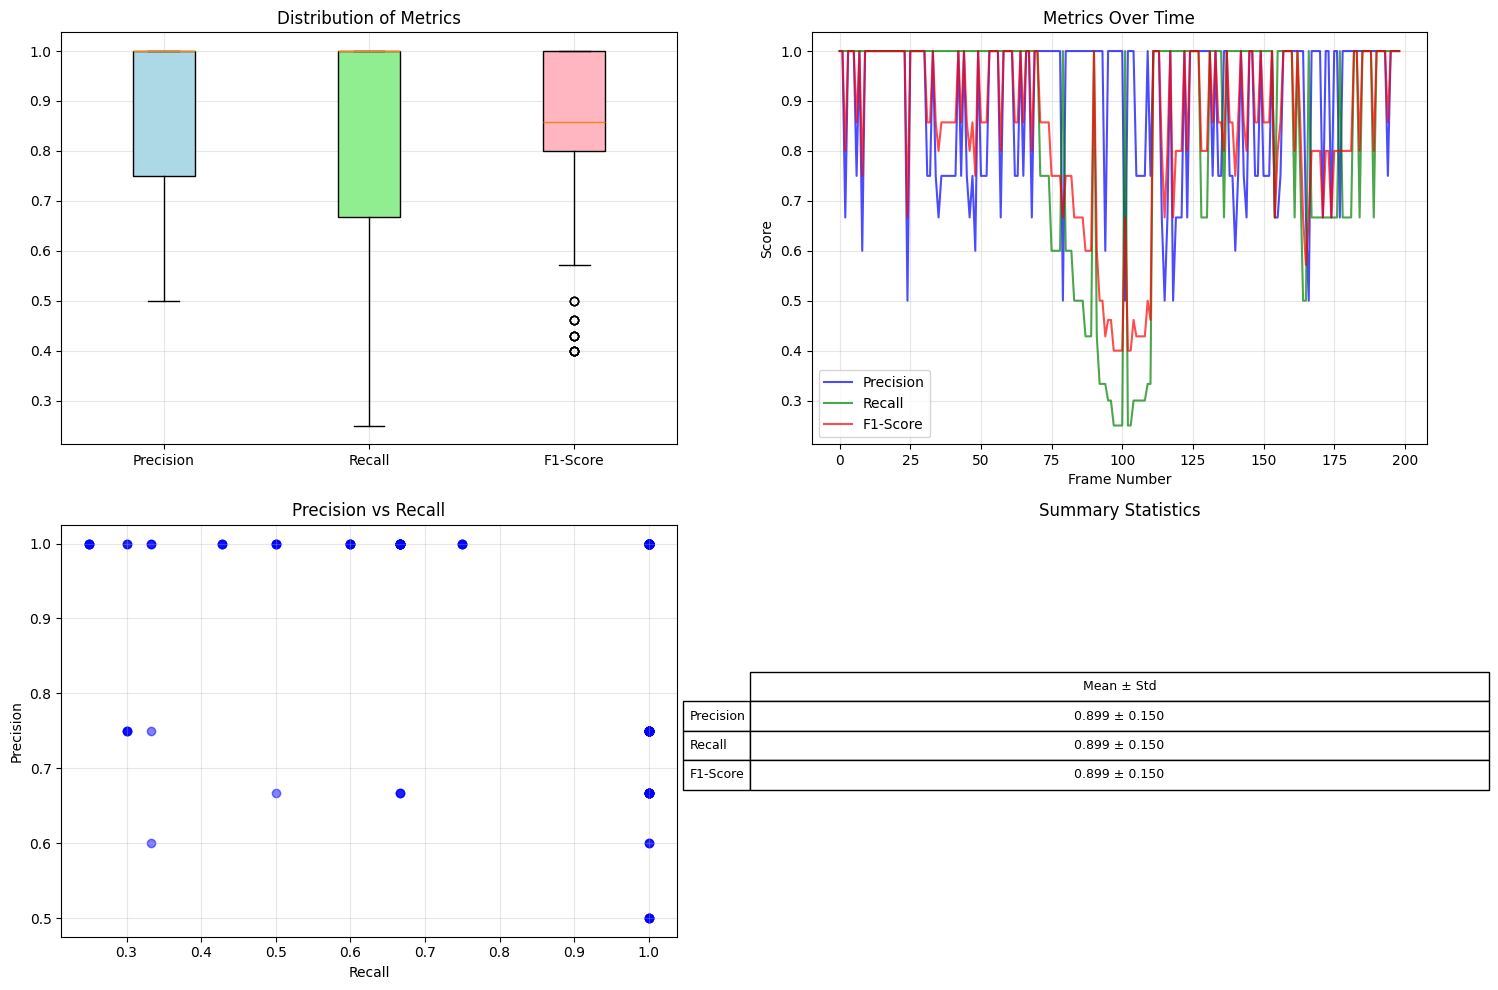

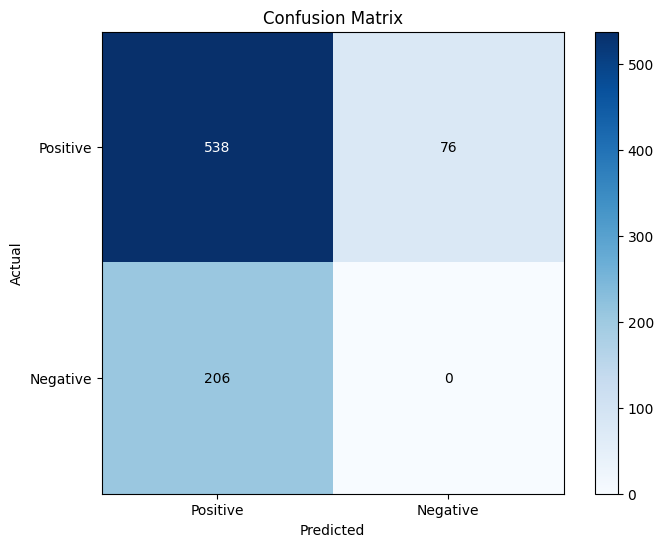

In [43]:
# Evaluate and visualize
print("Evaluating results...")
mean_metrics, detailed_metrics = evaluate_results(all_results)

# Print summary
print("\nEvaluation Summary:")
print(f"Mean Precision: {mean_metrics['mean_precision']:.4f}")
print(f"Mean Recall: {mean_metrics['mean_recall']:.4f}")
print(f"Mean F1-Score: {mean_metrics['mean_f1']:.4f}")

# Create visualizations
plot_evaluation_results(
    detailed_metrics['per_frame_precision'],
    detailed_metrics['per_frame_recall'],
    detailed_metrics['per_frame_f1'],
    save_path="evaluation_plots.png"
)

plot_confusion_matrix(
    detailed_metrics['total_tp'],
    detailed_metrics['total_fp'],
    detailed_metrics['total_fn'],
    save_path="confusion_matrix.png"
)

In [44]:
from ipywidgets import interact, IntSlider, Output, HBox, VBox
import IPython.display as display

def interactive_frame_viewer(dataset, all_results, config):
    """
    Create an interactive widget to view BEV visualizations frame by frame
    
    Args:
        dataset: The dataset containing BEV data
        all_results: List of dictionaries containing predictions and ground truth
        config: Configuration object for visualization
    """
    output = Output()
    
    def view_frame(frame_idx):
        with output:
            output.clear_output(wait=True)
            
            # Get BEV data and results for current frame
            bev, _ = dataset[frame_idx]
            result = all_results[frame_idx]
            
            # Create visualization
            visualize_bev(
                bev=bev.numpy(),  # Convert tensor to numpy if needed
                config=config,
                predictions=result['predictions'],
                ground_truth=result['ground_truth']
            )
            
            # Display frame metrics
            precision, recall, f1_score, (tp, fp, fn) = evaluate_detections(
                result['predictions'],
                result['ground_truth'],
                return_counts=True
            )
            
            print(f"\nFrame {frame_idx} Metrics:")
            print(f"Precision: {precision:.3f}")
            print(f"Recall: {recall:.3f}")
            print(f"F1-Score: {f1_score:.3f}")
            print(f"\nDetections:")
            print(f"True Positives: {tp}")
            print(f"False Positives: {fp}")
            print(f"False Negatives: {fn}")
    
    # Create the slider widget
    frame_slider = IntSlider(
        value=0,
        min=0,
        max=len(dataset)-1,
        step=1,
        description='Frame:',
        continuous_update=False,  # Only update when slider is released
        style={'description_width': 'initial'},
        layout={'width': '500px'}
    )
    
    # Create the interactive widget
    interactive_plot = interact(view_frame, frame_idx=frame_slider)
    
    # Display the widget and output area
    display.display(VBox([frame_slider, output]))

# Usage example:
def analyze_detections(all_results, dataset, config):
    """
    Run detection analysis with interactive visualization
    """
    
    # Create interactive viewer
    print("Use the slider to navigate through frames:")
    interactive_frame_viewer(dataset, all_results, config)
    
    return all_results

# Run the analysis:
all_results = analyze_detections(model, dataset, config, device)

Use the slider to navigate through frames:


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='5…